# 07 — Method of Moments: inferens på simulerede data

I denne notebook vil jeg bruger *method_of_moments* direkte på to-ø modellen og koalescenten. Jeg undersøger præcision, RMSE og hvad der sker, når jeg varierer stikprøvestørrelse og sande parameterværdier.

**Spørgsmål jeg gerne vil undersøger:**

- Hvad er MoM-estimaterne for et enkelt-parameter koalescent?
- Hvad sker der med RMSE for varierende $n_{obs}$ og $\theta$?
- Kan MoM estimere to parametre ($N$, $M$) i to-ø modellen?
- Hvad er MoMs begrænsninger?

In [1]:
# ALTID importer phasic først
from phasic import (
    Graph, with_ipv, GaussPrior,
    Adam, ExpStepSize, clear_caches,
    StateIndexer, Property
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'svg'
np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.dpi'] = 120
clear_caches()

  Removed 53 file(s), preserved directory structure
  Removed 178 file(s), preserved directory structure


## 1. Enkelt-parameter koalescent: MoM-basics

Jeg starter med eksempel fra MoM-tutorialen: en koalescent med ét parameter $\\theta$ (skaleret koalescensrate = $1/N$).

In [2]:
#  1-parameter koalescent fra MoM-tutorialen 
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)

# Sand parameter: theta = 7 (dvs. 1/N skaleret)
true_theta = [7]
graph.update_weights(true_theta)

# Simuler data
n_obs = 1000
observed_data = graph.sample(n_obs)

print(f"Sand theta:         {true_theta}")
print(f"Antal observationer:{n_obs}")
print(f"Stikprøvemiddel:    {np.mean(observed_data):.4f}")
print(f"Teoretisk mean:     {graph.expectation():.4f}")

Sand theta:         [7]
Antal observationer:1000
Stikprøvemiddel:    0.2151
Teoretisk mean:     0.2143


In [3]:
# Kør MoM — direkte fra vejleders tutorial
mom = graph.method_of_moments(observed_data)

print(f"Sand theta:       {true_theta}")
print(f"MoM estimat:      {mom.theta}")
print(f"Std fejl:         {mom.std}")
print(f"Konvergeret:      {mom.success}")
print(f"Residual:         {mom.residual:.2e}")
print(f"\nStikprøvemomenter: {mom.sample_moments}")
print(f"Modelmomenter:     {mom.model_moments}")

Sand theta:       [7]
MoM estimat:      [6.9801991]
Std fejl:         [0.15037796]
Konvergeret:      True
Residual:         5.35e-01

Stikprøvemomenter: [[0.21513785 0.06899956 0.03012612]]
Modelmomenter:     [0.21489358 0.06955394 0.03111853]


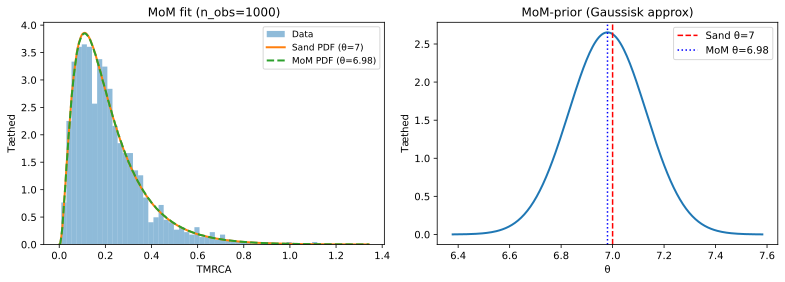

In [4]:
# Visualiser MoM-prior og data
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram + analytisk PDF
t_plot = np.linspace(0, max(observed_data)*1.2, 300)
axes[0].hist(observed_data, bins=50, density=True, alpha=0.5, label='Data')
graph.update_weights(true_theta)
axes[0].plot(t_plot, graph.pdf(t_plot), lw=2, label=f'Sand PDF (θ={true_theta[0]})')
graph.update_weights(mom.theta)
axes[0].plot(t_plot, graph.pdf(t_plot), '--', lw=2, label=f'MoM PDF (θ={mom.theta[0]:.2f})')
axes[0].set_xlabel('TMRCA'); axes[0].set_ylabel('Tæthed')
axes[0].set_title(f'MoM fit (n_obs={n_obs})')
axes[0].legend(fontsize=9)

# MoM-prior
if hasattr(mom, 'prior') and mom.prior:
    prior = mom.prior[0] if isinstance(mom.prior, list) else mom.prior
    theta_range = np.linspace(
        max(0.1, mom.theta[0] - 4*mom.std[0]),
        mom.theta[0] + 4*mom.std[0], 200)
    # Approksimer prior-tæthed som Gaussisk
    from scipy.stats import norm
    axes[1].plot(theta_range,
                 norm.pdf(theta_range, mom.theta[0], mom.std[0]),
                 lw=2)
    axes[1].axvline(true_theta[0], color='red', ls='--', lw=1.5, label=f'Sand θ={true_theta[0]}')
    axes[1].axvline(mom.theta[0], color='blue', ls=':', lw=1.5, label=f'MoM θ={mom.theta[0]:.2f}')
    axes[1].set_xlabel('θ'); axes[1].set_ylabel('Tæthed')
    axes[1].set_title('MoM-prior (Gaussisk approx)')
    axes[1].legend()

plt.tight_layout()
plt.show()
graph.update_weights(true_theta)  # reset

## RMSE som funktion af stikprøvestørrelse

**Eksperiment:** Kør MoM 50 gange for hvert $n_{obs} \in \{50, 100, 200, 500, 1000, 2000\}$ og beregn RMSE for theta-estimatet.

In [5]:
graph.update_weights(true_theta)
n_reps = 50
n_obs_values = [50, 100, 200, 500, 1000, 2000]

rmse_results = []
for n_obs_val in n_obs_values:
    estimates = []
    for _ in range(n_reps):
        data_rep = graph.sample(n_obs_val)
        try:
            mom_rep = graph.method_of_moments(data_rep)
            if mom_rep.success:
                estimates.append(float(mom_rep.theta[0]))
        except Exception:
            pass

    estimates = np.array(estimates)
    rmse = np.sqrt(np.mean((estimates - true_theta[0])**2))
    bias = np.mean(estimates) - true_theta[0]
    rmse_results.append({
        'n_obs': n_obs_val, 'rmse': rmse, 'bias': bias,
        'std': np.std(estimates), 'mean_est': np.mean(estimates),
        'n_converged': len(estimates)
    })
    print(f"n_obs={n_obs_val:5d}: RMSE={rmse:.4f}, bias={bias:.4f}, std={np.std(estimates):.4f}")

df_rmse = pd.DataFrame(rmse_results)

n_obs=   50: RMSE=0.8977, bias=0.3460, std=0.8283
n_obs=  100: RMSE=0.5439, bias=0.1552, std=0.5212
n_obs=  200: RMSE=0.3355, bias=0.0134, std=0.3353
n_obs=  500: RMSE=0.2301, bias=0.0056, std=0.2301
n_obs= 1000: RMSE=0.1676, bias=0.0234, std=0.1660
n_obs= 2000: RMSE=0.1074, bias=0.0331, std=0.1022


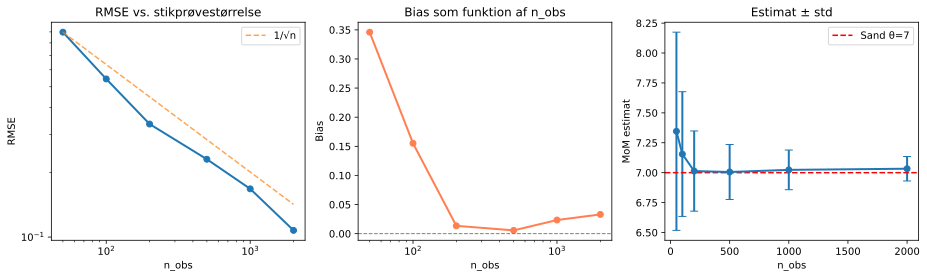

Observation:
- RMSE falder som 1/√n — MoM er konsistent.
- Bias er lille og falder med n.
- Selv n=200 giver relativt præcise estimater for dette model.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].loglog(df_rmse['n_obs'], df_rmse['rmse'], 'o-', lw=2)
# Teoretisk 1/sqrt(n) konvergens
n_fine = np.logspace(np.log10(50), np.log10(2000), 50)
scale = df_rmse['rmse'].iloc[0] * np.sqrt(df_rmse['n_obs'].iloc[0])
axes[0].loglog(n_fine, scale/np.sqrt(n_fine), '--', alpha=0.7, label='1/√n')
axes[0].set_xlabel('n_obs'); axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs. stikprøvestørrelse')
axes[0].legend()

axes[1].semilogx(df_rmse['n_obs'], df_rmse['bias'], 'o-', color='coral', lw=2)
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].set_xlabel('n_obs'); axes[1].set_ylabel('Bias')
axes[1].set_title('Bias som funktion af n_obs')

axes[2].errorbar(df_rmse['n_obs'], df_rmse['mean_est'],
                 yerr=df_rmse['std'], fmt='o-', capsize=4, lw=2)
axes[2].axhline(true_theta[0], color='red', ls='--', lw=1.5, label=f'Sand θ={true_theta[0]}')
axes[2].set_xlabel('n_obs'); axes[2].set_ylabel('MoM estimat')
axes[2].set_title('Estimat ± std')
axes[2].legend()

plt.tight_layout()
plt.show()
print("Observation:")
print("- RMSE falder som 1/√n — MoM er konsistent.")
print("- Bias er lille og falder med n.")
print("- Selv n=200 giver relativt præcise estimater for dette model.")

## 3. To-parameter two-island model: MoM for ($1/N$, $M$)

Jeg bruger two-island StateIndexer-implementering med to parametre, og kører MoM for at estimere begge.

In [7]:
# To-parameter two-island model (vejlederens StateIndexer tilgang) 
nr_samples_ti = 2

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_ti),
        Property('pop2', min_value=0, max_value=nr_samples_ti),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_ti

@with_ipv(initial)
def coalescent_islands(state):
    """Two-island model med to parametre: [1/N, M/2].
    Tilstanden tracker pop1/pop2-efterkommere og hvilken ø linje er på.
    """
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            child = state.copy()
            child[i] -= 1; child[j] -= 1
            dp1 = props_i.pop1 + props_j.pop1
            dp2 = props_i.pop2 + props_j.pop2
            if dp1 <= nr_samples_ti and dp2 <= nr_samples_ti:
                k = indexer.descendants.props_to_index(pop1=dp1, pop2=dp2, in_pop=props_i.in_pop)
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child[i] -= 1
            k = indexer.descendants.props_to_index(pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)
            child[k] += 1
            transitions.append([child, [0, state[i]]])
    return transitions

graph_ti = Graph(coalescent_islands)
graph_ti.plot()
print(f"Antal tilstande: {graph_ti.vertices_length()}")

Antal tilstande: 6


Sand theta:    [0.7, 0.9]
MoM estimat:   ['0.7259', '0.8671']
Std fejl:      ['0.0253', '0.3257']
Konvergeret:   True


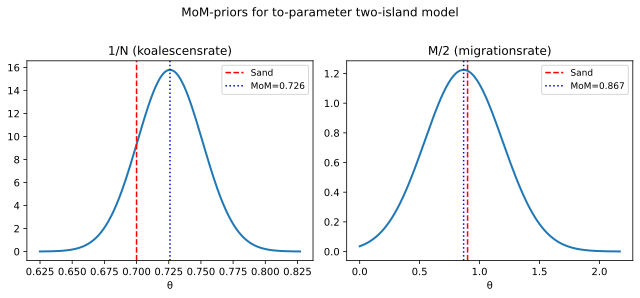

In [8]:
# Sand parametre: [1/N, M/2]
true_theta_ti = [0.7, 0.9]  # fra vejlederens tutorial
graph_ti.update_weights(true_theta_ti)

n_obs_ti = 1000
data_ti = graph_ti.sample(n_obs_ti)

mom_ti = graph_ti.method_of_moments(data_ti)

print(f"Sand theta:    {true_theta_ti}")
print(f"MoM estimat:   {[f'{v:.4f}' for v in mom_ti.theta]}")
print(f"Std fejl:      {[f'{v:.4f}' for v in mom_ti.std]}")
print(f"Konvergeret:   {mom_ti.success}")

# Plot MoM-priors
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
param_names = ['1/N (koalescensrate)', 'M/2 (migrationsrate)']
from scipy.stats import norm
for i, (ax, name) in enumerate(zip(axes, param_names)):
    mu = float(mom_ti.theta[i])
    sig = float(mom_ti.std[i])
    x_r = np.linspace(max(0, mu - 4*sig), mu + 4*sig, 200)
    ax.plot(x_r, norm.pdf(x_r, mu, sig), lw=2)
    ax.axvline(true_theta_ti[i], color='red', ls='--', lw=1.5, label='Sand')
    ax.axvline(mu, color='blue', ls=':', lw=1.5, label=f'MoM={mu:.3f}')
    ax.set_title(name); ax.set_xlabel('θ'); ax.legend(fontsize=9)
plt.suptitle('MoM-priors for to-parameter two-island model', y=1.02)
plt.tight_layout()
plt.show()

## 4. RMSE for to-parameter MoM: parameter-grid

**Eksperiment:** Scan over sande $(N, M)$-værdier og beregn RMSE.
Hvornår er MoM præcis? Hvornår fejler den?

In [ ]:
theta0_vals = [0.3, 0.7, 1.5]   # 1/N: lav N = høj, høj N = lav
theta1_vals = [0.2, 0.9, 2.0]   # M/2
n_reps_grid = 30
n_obs_grid = 500

grid_results = []
for t0 in theta0_vals:
    for t1 in theta1_vals:
        true_t = [t0, t1]
        graph_ti.update_weights(true_t)
        ests = []
        for _ in range(n_reps_grid):
            d = graph_ti.sample(n_obs_grid)
            try:
                m = graph_ti.method_of_moments(d)
                if m.success:
                    ests.append([float(m.theta[0]), float(m.theta[1])])
            except Exception:
                pass
        ests = np.array(ests) if ests else np.array([[np.nan, np.nan]])
        rmse0 = np.sqrt(np.nanmean((ests[:, 0] - t0)**2))
        rmse1 = np.sqrt(np.nanmean((ests[:, 1] - t1)**2))
        grid_results.append({
            'theta0_true': t0, 'theta1_true': t1,
            'rmse_theta0': rmse0, 'rmse_theta1': rmse1,
            'n_converged': len(ests)
        })

df_grid = pd.DataFrame(grid_results)
print("RMSE for parameter-grid (n_obs=500):")
print(df_grid.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

In [ ]:
# Scatter-plot: estimerede vs. sande parametre
graph_ti.update_weights([0.7, 0.9])
ests_scatter = []
for _ in range(100):
    d = graph_ti.sample(500)
    try:
        m = graph_ti.method_of_moments(d)
        if m.success:
            ests_scatter.append([float(m.theta[0]), float(m.theta[1])])
    except Exception:
        pass
ests_scatter = np.array(ests_scatter)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (ax, name, true_val) in enumerate(zip(axes, ['1/N', 'M/2'], [0.7, 0.9])):
    ax.hist(ests_scatter[:, i], bins=25, density=True, alpha=0.7)
    ax.axvline(true_val, color='red', ls='--', lw=2, label=f'Sand={true_val}')
    ax.axvline(np.mean(ests_scatter[:, i]), color='blue', ls=':', lw=1.5,
               label=f'Gns={np.mean(ests_scatter[:,i]):.3f}')
    ax.set_xlabel(f'θ_{i} ({name})')
    ax.set_title(f'MoM fordelng: {name} (100 runs)')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Observation:")
print("- θ0 (1/N) estimeres præcist med lille varians.")
print("- θ1 (M/2) har større varians — migration er sværere at estimere.")

## Multi-feature MoM: SFS som features

Jeg bruger *dense_to_sparse*-tilgang til at køre MoM på separate grenlængder (singletons, doubletons, tripletons) som features.

In [ ]:
from phasic import dense_to_sparse

# Standard koalescent med 1 parameter og reward-features
graph_1p = Graph(coalescent_1param)
true_theta_1p = [7]
graph_1p.update_weights(true_theta_1p)

# Reward-matrix: én row per linje-type (singletons, doubletons, tripletons)
states = graph_1p.states().T
rewards = states[:-1]  # springer 4-ton over (altid 0)
n_features = rewards.shape[0]
print(f"Reward-matrix form: {rewards.shape}  (n_features={n_features})")
print(f"Rewards:\n{rewards}")

# Simuler multi-feature data
n_obs_mf = 5000
observed_2d = np.full((n_obs_mf * n_features, n_features), np.nan)
for i in range(n_features):
    observed_2d[i*n_obs_mf:(i+1)*n_obs_mf, i] = graph_1p.sample(n_obs_mf, rewards=rewards[i])

sparse_data = dense_to_sparse(observed_2d)

# MoM med multi-feature
mom_mf = graph_1p.method_of_moments(sparse_data, rewards=rewards)

print(f"\nSand theta:          {true_theta_1p}")
print(f"MoM (multi-feature): {mom_mf.theta}")
print(f"Std fejl:            {mom_mf.std}")
print(f"Konvergeret:         {mom_mf.success}")
print(f"\nStikprøvemomenter (per feature):")
print(mom_mf.sample_moments)
print(f"\nModelmomenter:")
print(mom_mf.model_moments)

In [ ]:
# Sammenlign enkelt-feature vs. multi-feature MoM
n_reps_comp = 40
n_obs_comp = 1000
graph_1p.update_weights(true_theta_1p)

single_ests, multi_ests = [], []

for _ in range(n_reps_comp):
    # Single feature
    d_single = graph_1p.sample(n_obs_comp)
    try:
        m_s = graph_1p.method_of_moments(d_single)
        if m_s.success: single_ests.append(float(m_s.theta[0]))
    except Exception: pass

    # Multi-feature
    d_2d = np.full((n_obs_comp * n_features, n_features), np.nan)
    for i in range(n_features):
        d_2d[i*n_obs_comp:(i+1)*n_obs_comp, i] = graph_1p.sample(n_obs_comp, rewards=rewards[i])
    try:
        m_m = graph_1p.method_of_moments(dense_to_sparse(d_2d), rewards=rewards)
        if m_m.success: multi_ests.append(float(m_m.theta[0]))
    except Exception: pass

single_ests = np.array(single_ests)
multi_ests = np.array(multi_ests)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(single_ests, bins=20, alpha=0.6, density=True, label=f'Single-feature RMSE={np.sqrt(np.mean((single_ests-7)**2)):.3f}')
ax.hist(multi_ests, bins=20, alpha=0.6, density=True, label=f'Multi-feature RMSE={np.sqrt(np.mean((multi_ests-7)**2)):.3f}')
ax.axvline(7, color='red', ls='--', lw=2, label='Sand θ=7')
ax.set_xlabel('θ estimat'); ax.set_ylabel('Tæthed')
ax.set_title(f'MoM: single vs. multi-feature (n_obs={n_obs_comp})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Observation: Multi-feature MoM kan have lavere RMSE fordi")
print("SFS-informationen fra alle grenlængder udnyttes.")

## MoM's begrænsninger: identifikabilitetsproblemer

**Eksperiment:** Find to $(N, M)$-kombinationer med næsten identisk $\mathbb{E}[T_{\text{MRCA}}]$ og vis at MoM kan forveksle dem.

In [ ]:
# To parameterpar med næsten ens E[TMRCA]
combos = [
    [0.7, 0.9],   # original
    [0.5, 0.4],   # lavere N, lavere M
    [1.2, 2.5],   # højere N, højere M
]

print("E[TMRCA] og Var[TMRCA] for de tre parameter-kombinationer:")
for combo in combos:
    graph_ti.update_weights(combo)
    print(f"  theta={combo}: E[TMRCA]={graph_ti.expectation():.4f}, Var={graph_ti.variance():.4f}")

print("\nObservation: Modeller med ens E[TMRCA] kan have forskellig Var.")
print("MoM der kun bruger ét moment kan ikke skelne dem — brug af varians som")
print("ekstra moment hjælper, men grundlæggende identifikabilitetsproblemer")
print("kan kun løses med mere information (SVGD med fuld likelihood).")

## Opsummering

| Analyse | Nøgleresultat |
|---|---|
| RMSE vs. n_obs | RMSE falder som 1/√n — MoM er konsistent |
| To-parameter two-island | M-raten er sværere at estimere end N |
| Multi-feature MoM | SFS-features kan give lavere RMSE |
| Identifikabilitet | Modeller med ens mean men forskellig varians kræver SVGD |

**Næste notebook:** 08_svgd_inference.ipynb — Bayesiansk inferens med SVGD.